# 06 Lag Diagnostics (Descriptive)

Modest lag diagnostics on the combined monthly polling panel



In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PANEL_DIR = PROJECT_ROOT / 'data' / 'panel'
FIGURES_DIR = PROJECT_ROOT / 'figures' / '06_notebook_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANEL_PARQUET = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.parquet'
PANEL_CSV = PANEL_DIR / 'monthly_salience_polling_panel_combined_2013_2025.csv'
OUT_LAG_CSV = PANEL_DIR / 'lag_diagnostics_descriptive_summary.csv'

EXPECTED_START = pd.Timestamp('2013-09-01')
EXPECTED_END = pd.Timestamp('2025-12-31')
EXPECTED_ROWS = 148

In [2]:
def load_panel(parquet_path: Path, csv_path: Path) -> pd.DataFrame:
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'Missing panel file: {parquet_path} and {csv_path}')

panel = load_panel(PANEL_PARQUET, PANEL_CSV).copy()
panel['month_dt'] = pd.to_datetime(panel['month_dt'], errors='coerce')
panel['year_month'] = panel['month_dt'].dt.strftime('%Y-%m')

required_cols = [
    'year_month', 'month_dt', 'afd_poll_support_mean', 'nexis_total_results',
    'polling_source_block', 'n_polls'
]
missing_req = [c for c in required_cols if c not in panel.columns]
if missing_req:
    raise ValueError(f'Missing required columns: {missing_req}')

if 'media_salience_volume_log1p' not in panel.columns and 'media_salience_log1p' not in panel.columns:
    print('Compute log1p from Nexis.')

if ('media_salience_volume_z_panel' not in panel.columns) and ('media_salience_volume_z' not in panel.columns):
    raise ValueError('Missing both media_salience_volume_z_panel and media_salience_volume_z')

if panel['afd_poll_support_mean'].isna().any():
    raise ValueError('afd_poll_support_mean contains missing values')
if panel['nexis_total_results'].isna().any():
    raise ValueError('nexis_total_results contains missing values')
if panel['month_dt'].isna().any():
    raise ValueError('month_dt contains parse failures')
if panel['year_month'].duplicated().any():
    raise ValueError('Panel has duplicate months')

panel = panel.sort_values('month_dt').reset_index(drop=True)

if panel['month_dt'].min().to_period('M') != EXPECTED_START.to_period('M') or panel['month_dt'].max().to_period('M') != EXPECTED_END.to_period('M'):
    raise ValueError(f'Unexpected coverage: {panel["month_dt"].min()} to {panel["month_dt"].max()}')
if len(panel) != EXPECTED_ROWS:
    raise ValueError(f'Unexpected row count: {len(panel)} (expected {EXPECTED_ROWS})')

if 'retrieval_mismatch_flag' in panel.columns:
    mismatch_count = int(panel['retrieval_mismatch_flag'].fillna(False).astype(bool).sum())
    if mismatch_count != 0:
        raise ValueError(f'retrieval_mismatch_flag has {mismatch_count} true values')

In [3]:
def zscore(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    mu = s.mean()
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - mu) / sd

panel['afd_poll_support_change'] = panel['afd_poll_support_mean'].diff()
panel['nexis_total_results_change'] = panel['nexis_total_results'].diff()

if 'media_salience_volume_log1p' in panel.columns:
    panel['media_salience_log1p'] = pd.to_numeric(panel['media_salience_volume_log1p'], errors='coerce')
elif 'media_salience_log1p' in panel.columns:
    panel['media_salience_log1p'] = pd.to_numeric(panel['media_salience_log1p'], errors='coerce')
else:
    panel['media_salience_log1p'] = np.log1p(pd.to_numeric(panel['nexis_total_results'], errors='coerce'))

panel['media_salience_log1p_change'] = panel['media_salience_log1p'].diff()
panel['afd_poll_support_z_combined'] = zscore(panel['afd_poll_support_mean'])

if 'media_salience_volume_z_panel' in panel.columns:
    panel['media_salience_z_combined'] = pd.to_numeric(panel['media_salience_volume_z_panel'], errors='coerce')
else:
    panel['media_salience_z_combined'] = pd.to_numeric(panel['media_salience_volume_z'], errors='coerce')

for lag in range(0, 7):
    panel[f'media_salience_z_lag{lag}'] = panel['media_salience_z_combined'].shift(lag)
    panel[f'media_salience_log1p_lag{lag}'] = panel['media_salience_log1p'].shift(lag)
    panel[f'nexis_total_results_lag{lag}'] = panel['nexis_total_results'].shift(lag)

In [4]:
def corr_with_n(df: pd.DataFrame, x: str, y: str) -> tuple[float, int]:
    tmp = df[[x, y]].dropna()
    n = len(tmp)
    if n < 2:
        return (np.nan, n)
    return (tmp[x].corr(tmp[y]), n)

samples = {
    'combined_all': panel,
    'historical_manual_wahlrecht': panel[panel['polling_source_block'] == 'historical_manual_wahlrecht'].copy(),
    'dawum': panel[panel['polling_source_block'] == 'dawum'].copy(),
}

pairs = [
    ('media_salience_z', 'afd_level', 'media_salience_z_lag{lag}', 'afd_poll_support_mean'),
    ('media_salience_z', 'afd_change', 'media_salience_z_lag{lag}', 'afd_poll_support_change'),
    ('media_salience_log1p', 'afd_level', 'media_salience_log1p_lag{lag}', 'afd_poll_support_mean'),
    ('media_salience_log1p', 'afd_change', 'media_salience_log1p_lag{lag}', 'afd_poll_support_change'),
]

rows = []
for sample_name, sdf in samples.items():
    for lag in range(0, 7):
        for x_family, y_family, x_tpl, y_var in pairs:
            x_var = x_tpl.format(lag=lag)
            corr, n_used = corr_with_n(sdf, x_var, y_var)
            rows.append({
                'sample': sample_name,
                'lag_months': lag,
                'x_variable': x_var,
                'y_variable': y_var,
                'correlation': corr,
                'n_used': n_used,
                'notes': 'Descriptive lag correlation only; non-causal and source-boundary sensitive.'
            })

lag_summary = pd.DataFrame(rows)
lag_summary.to_csv(OUT_LAG_CSV, index=False)

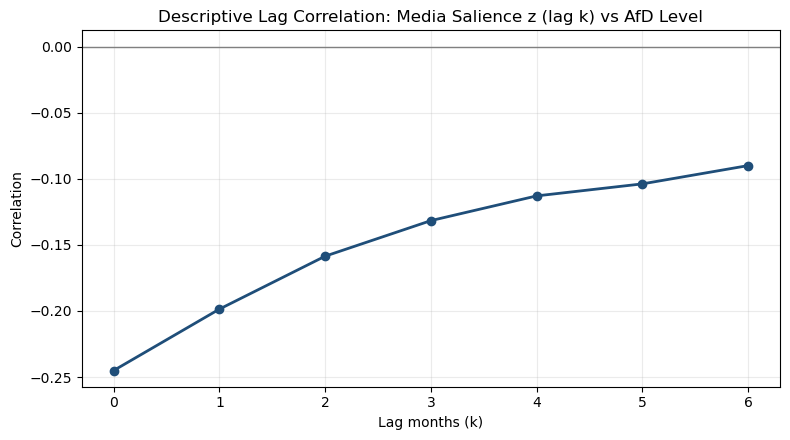

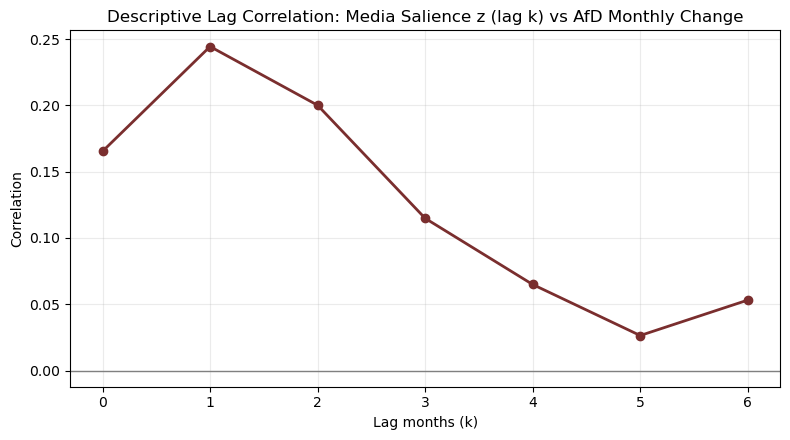

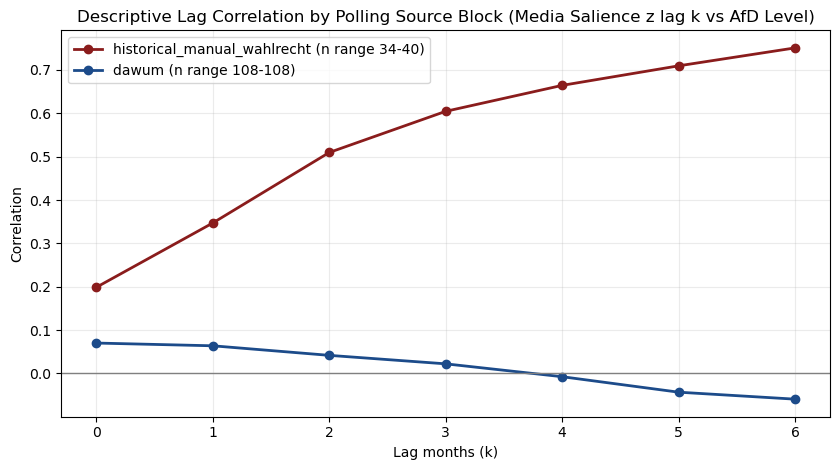

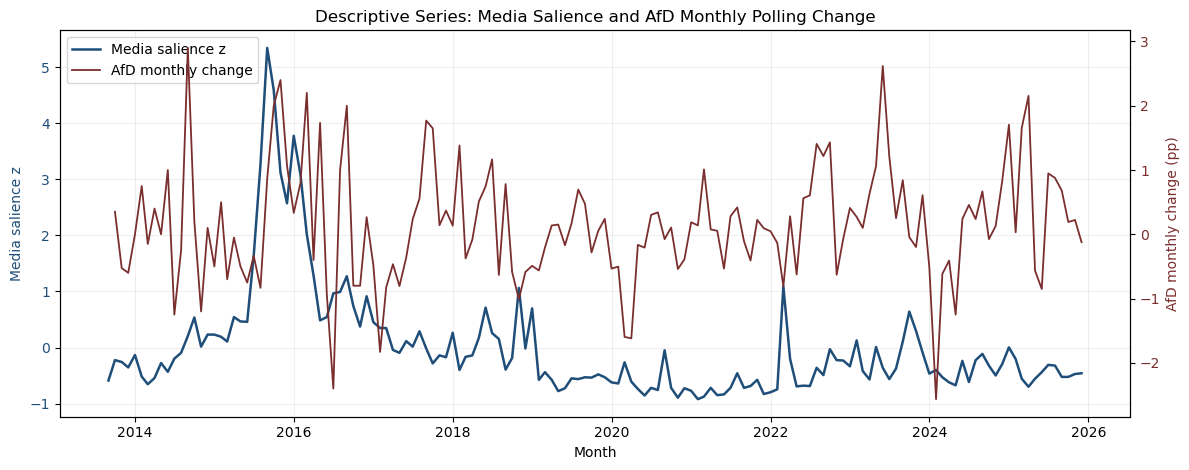

In [5]:
                                                            
plot1 = lag_summary[(lag_summary['sample'] == 'combined_all') & (lag_summary['x_variable'].str.startswith('media_salience_z_lag')) & (lag_summary['y_variable'] == 'afd_poll_support_mean')].copy()
plot1 = plot1.sort_values('lag_months')

plt.figure(figsize=(8, 4.5))
plt.plot(plot1['lag_months'], plot1['correlation'], marker='o', linewidth=2, color='#1f4e79')
plt.axhline(0, color='gray', linewidth=1)
plt.title('Descriptive Lag Correlation: Media Salience z (lag k) vs AfD Level')
plt.xlabel('Lag months (k)')
plt.ylabel('Correlation')
plt.grid(alpha=0.25)
out1 = FIGURES_DIR / 'lag_correlations_media_z_vs_afd_level.png'
plt.tight_layout(); plt.savefig(out1, dpi=150); plt.show()

                                                             
plot2 = lag_summary[(lag_summary['sample'] == 'combined_all') & (lag_summary['x_variable'].str.startswith('media_salience_z_lag')) & (lag_summary['y_variable'] == 'afd_poll_support_change')].copy()
plot2 = plot2.sort_values('lag_months')

plt.figure(figsize=(8, 4.5))
plt.plot(plot2['lag_months'], plot2['correlation'], marker='o', linewidth=2, color='#7a2e2e')
plt.axhline(0, color='gray', linewidth=1)
plt.title('Descriptive Lag Correlation: Media Salience z (lag k) vs AfD Monthly Change')
plt.xlabel('Lag months (k)')
plt.ylabel('Correlation')
plt.grid(alpha=0.25)
out2 = FIGURES_DIR / 'lag_correlations_media_z_vs_afd_change.png'
plt.tight_layout(); plt.savefig(out2, dpi=150); plt.show()

                                                     
plot3 = lag_summary[(lag_summary['sample'].isin(['historical_manual_wahlrecht','dawum'])) & (lag_summary['x_variable'].str.startswith('media_salience_z_lag')) & (lag_summary['y_variable'] == 'afd_poll_support_mean')].copy()
plot3 = plot3.sort_values(['sample','lag_months'])

plt.figure(figsize=(8.5, 4.8))
for s, color in [('historical_manual_wahlrecht', '#8a1c1c'), ('dawum', '#1c4b8a')]:
    sub = plot3[plot3['sample'] == s]
    label = f"{s} (n range {int(sub['n_used'].min())}-{int(sub['n_used'].max())})"
    plt.plot(sub['lag_months'], sub['correlation'], marker='o', linewidth=2, label=label, color=color)
plt.axhline(0, color='gray', linewidth=1)
plt.title('Descriptive Lag Correlation by Polling Source Block (Media Salience z lag k vs AfD Level)')
plt.xlabel('Lag months (k)')
plt.ylabel('Correlation')
plt.grid(alpha=0.25)
plt.legend(loc='best')
out3 = FIGURES_DIR / 'lag_correlations_by_source_block.png'
plt.tight_layout(); plt.savefig(out3, dpi=150); plt.show()

                                                                 
fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(panel['month_dt'], panel['media_salience_z_combined'], color='#1f4e79', linewidth=1.8, label='Media salience z')
ax1.set_ylabel('Media salience z', color='#1f4e79')
ax1.tick_params(axis='y', labelcolor='#1f4e79')
ax1.grid(alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(panel['month_dt'], panel['afd_poll_support_change'], color='#7a2e2e', linewidth=1.3, label='AfD monthly change')
ax2.set_ylabel('AfD monthly change (pp)', color='#7a2e2e')
ax2.tick_params(axis='y', labelcolor='#7a2e2e')

ax1.set_title('Descriptive Series: Media Salience and AfD Monthly Polling Change')
ax1.set_xlabel('Month')

h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')
out4 = FIGURES_DIR / 'media_salience_and_afd_change_descriptive.png'
fig.tight_layout(); fig.savefig(out4, dpi=150); plt.show()

In [6]:
                                             
summary_level = lag_summary[(lag_summary['sample'] == 'combined_all') & (lag_summary['x_variable'].str.startswith('media_salience_z_lag')) & (lag_summary['y_variable'] == 'afd_poll_support_mean')].sort_values('correlation', ascending=False)
summary_change = lag_summary[(lag_summary['sample'] == 'combined_all') & (lag_summary['x_variable'].str.startswith('media_salience_z_lag')) & (lag_summary['y_variable'] == 'afd_poll_support_change')].sort_values('correlation', ascending=False)


for s in ['historical_manual_wahlrecht','dawum']:
    row = lag_summary[(lag_summary['sample']==s) & (lag_summary['lag_months']==0) & (lag_summary['x_variable']=='media_salience_z_lag0') & (lag_summary['y_variable']=='afd_poll_support_mean')]
    print(s, row[['correlation','n_used']].to_dict(orient='records'))

historical_manual_wahlrecht [{'correlation': 0.19877876320088197, 'n_used': 40}]
dawum [{'correlation': 0.07019560682689899, 'n_used': 108}]
